<a href="https://colab.research.google.com/github/KANGWEII/hands_on_ml/blob/feature-chapter_7/Chapter07/ensemble_learning_and_random_forests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 7: Ensemble Learning and Random Forests

- A group of predictors is called an *ensemble* (ensemble learning)
- An ensemble learning algorithm is called an *ensemble method*
- eg. ensemble method
  - Train a group of decision tree classifiers, each on random subset of training set
  - Ensemble of decision trees is called a *random forest*
- Popular ensemble methods
  - voting classifiers
  - bagging and pasting ensembles
  - random forests
  - boosting
  - stacking ensembles

## Voting Classifiers

- The law of large numbers
  - As you repeat a random experiment more and more times, the average result gets closer to the expected (true) value.
- The plot below shows why voting classifier often achieves a higher accuracy than the best classifier in the ensemble, even if each classifier is a weak learner

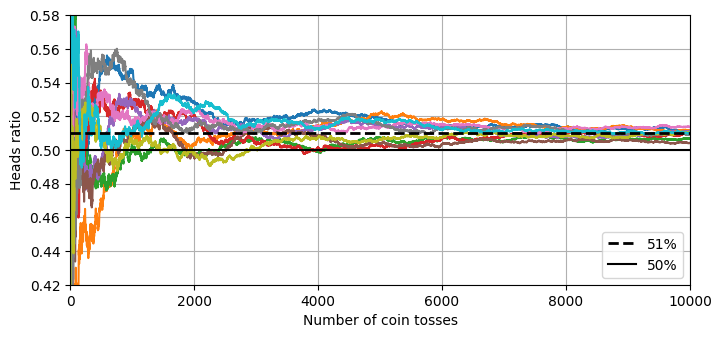

In [1]:
# Analogy for a slightly biased coin that has 51% chance of coming up heads and 49$ chance of coming up tails

import matplotlib.pyplot as plt
import numpy as np

heads_proba = 0.51
np.random.seed(42)
coin_tosses = (np.random.rand(10000, 10) < heads_proba).astype(np.int32)
cumulative_heads = coin_tosses.cumsum(axis=0)
cumulative_heads_ratio = cumulative_heads / np.arange(1, 10001).reshape(-1, 1)

plt.figure(figsize=(8, 3.5))
plt.plot(cumulative_heads_ratio)
plt.plot([0, 10000], [0.51, 0.51], "k--", linewidth=2, label="51%")
plt.plot([0, 10000], [0.5, 0.5], "k-", label="50%")
plt.xlabel("Number of coin tosses")
plt.ylabel("Heads ratio")
plt.legend(loc="lower right")
plt.axis([0, 10000, 0.42, 0.58])
plt.grid()

plt.show()

- Ensemble methods work best when the predictors are as independent from one another as possible
- Train with very different algorithms to get diverse classifiers

In [2]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

X, y = make_moons(n_samples=500, noise=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

voting_clf = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(random_state=42)),
        ('rf', RandomForestClassifier(random_state=42)),
        ('svc', SVC(random_state=42))
    ]
)

voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('lr', LogisticRegression(random_state=42)),
                             ('rf', RandomForestClassifier(random_state=42)),
                             ('svc', SVC(random_state=42))])

In [3]:
# Performace of each individual classifier
for name, clf in voting_clf.named_estimators_.items():
    print(name, clf.score(X_test, y_test))

lr 0.864
rf 0.896
svc 0.896


In [4]:
# Hard voting based on majority votes

print(voting_clf.predict(X_test[:1]))
print()
print([clf.predict(X_test[:1]) for clf in voting_clf.estimators_])

[1]

[array([1]), array([1]), array([0])]


In [5]:
# Performance on the test set
voting_clf.score(X_test, y_test)

0.912

- Soft voting: predict the class with the highest probability, averaged over all the individual classifiers
- Classifiers that are able to estimate class probabilities have a *predict_proba()* method
- Often achieves higher performance than hard voting

In [6]:
voting_clf.voting = "soft"

# SVC requires to use cross-validation to estimate the class probabilities by setting the hyperparameter
voting_clf.named_estimators["svc"].probability = True

voting_clf.fit(X_train, y_train)

voting_clf.score(X_test, y_test)

0.92

## Bagging and Pasting

- Bagging
  - Sampling is performed with replacement
  - Imagine drawing an item from a bag, put it back, then draw again
  - Some samples appear multiple times
  - Each model sees duplicates

- Pasting
  - Sample the training data without replacement
  - Train one model per subset
  - Each model sees different subsets
  - Cut the dataset into different pieces

- Both bagging and pasting allow training instances to be sampled several times across multiple predictors
- But only bagging allows training instances to be sampled several times for the same predictor

### Bagging and Pasting in Scikit-Learn

- BaggingClassifier for classification
- BaggingRegressor for regression
- Set *boot_strap=False* to use pasting

In [7]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=500, max_samples=100, n_jobs=-1, random_state=42)

bag_clf.fit(X_train, y_train)
bag_clf.score(X_test, y_test)

0.904

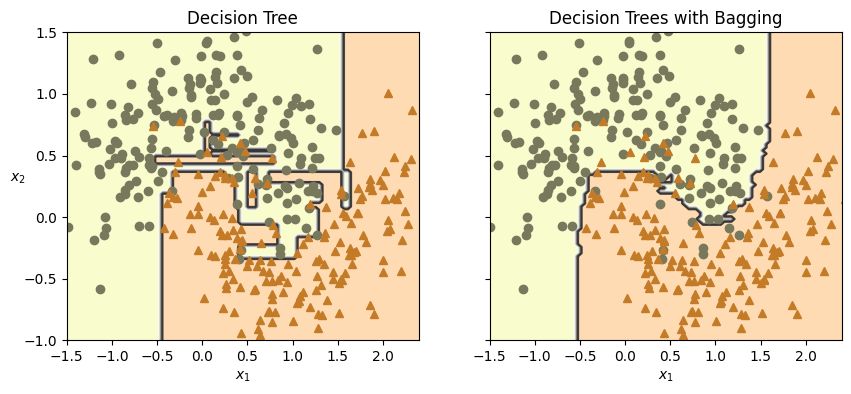

In [8]:
def plot_decision_boundary(clf, X, y, alpha=1.0):
    axes=[-1.5, 2.4, -1, 1.5]
    x1, x2 = np.meshgrid(np.linspace(axes[0], axes[1], 100),
                         np.linspace(axes[2], axes[3], 100))
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)

    plt.contourf(x1, x2, y_pred, alpha=0.3 * alpha, cmap='Wistia')
    plt.contour(x1, x2, y_pred, cmap="Greys", alpha=0.8 * alpha)
    colors = ["#78785c", "#c47b27"]
    markers = ("o", "^")
    for idx in (0, 1):
        plt.plot(X[:, 0][y == idx], X[:, 1][y == idx],
                 color=colors[idx], marker=markers[idx], linestyle="none")
    plt.axis(axes)
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$", rotation=0)

tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)
plt.sca(axes[0])
plot_decision_boundary(tree_clf, X_train, y_train)
plt.title("Decision Tree")
plt.sca(axes[1])
plot_decision_boundary(bag_clf, X_train, y_train)
plt.title("Decision Trees with Bagging")
plt.ylabel("")

plt.show()

### Out-of-Bag Evaluation

- Only about 63% of the training instances are sampled on average for each predictor
- The remaining 37% training instances that are not sampled are called *out-of-bag (OOB)* instances
- Bagging ensemble can be evaluated using OOB instances

If you randomly draw one instance from a dataset of size m, each instance in the dataset obviously has probability 1/m of getting picked, and therefore it has a probability 1 – 1/m of not getting picked. If you draw m instances with replacement, all draws are independent and therefore each instance has a probability (1 – 1/m)m of not getting picked. Now let's use the fact that exp(x) is equal to the limit of (1 + x/m)m as m approaches infinity. So if m is large, the ratio of out-of-bag instances will be about exp(–1) ≈ 0.37. So roughly 63% (1 – 0.37) will be sampled.

In [11]:
print(1 - (1 - 1 / 1000) ** 1000)
print(1 - np.exp(-1))

0.6323045752290363
0.6321205588285577


In [9]:
# OOB Evaluation

bag_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=500, oob_score=True, n_jobs=-1, random_state=42)

bag_clf.fit(X_train, y_train)
bag_clf.oob_score_

0.896

- The BaggingClassifier is likely to achieve about 89.6% accuracy on the test set
- Below code verify using accuracy_score

In [10]:
from sklearn.metrics import accuracy_score

y_pred = bag_clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.92

- OOB evaluation was a bit too pessimistic

In [12]:
# OOB decision function for each training instance
# First instance has 67.6% probability of belonging to the positive class and 32.4% of negative class

bag_clf.oob_decision_function_[:3]

array([[0.32352941, 0.67647059],
       [0.3375    , 0.6625    ],
       [1.        , 0.        ]])

### Random Patches and Random Subspaces

- BaggingClassifier sampling is controlled by two hyperparameters
  - max_features
  - bootstrap_features
- Both same as max_samples and botstrap but for feature sampling instead of instance sampling
- Each predictor will be trained on a random subset of the input features
- Useful when  dealing with high-dimensional inputs\
- Sampling both training instances and features is called the *random patches* method
- Sampling features results in even more predictor diversity, trading a bit more bias for a lower variance